# CIFAR-100 Image Classification

CIFAR-100 is a dataset consisting of 60,000 32x32 color images in 100 classes, with 600 images per class. There are 50,000 training images and 10,000 test images.

## Project Agenda and Setup:
1.  **Dataset Setup:**
    *   Load the CIFAR-100 dataset.
    *   Preprocess the data (normalize pixel values, one-hot encode labels).
    *   Verify the shapes of the processed data.

2.  **Model Building:**
    *   Adapt the ANN and CNN model architectures for the CIFAR-100 dataset. Consider that CIFAR-100 images are color (3 channels) and have a different resolution (32x32). You might need to adjust the input layer and potentially the number of filters or layers in the CNNs for better performance on a more complex dataset.

3.  **Model Training:**
    *   Train the models using the preprocessed CIFAR-100 training data. Use Early Stopping and Model Checkpointing as implemented before.

4.  **Model Evaluation:**
    *   Evaluate the trained models on the CIFAR-100 test set. Compare their performance using loss and accuracy.
    *   Visualize training history and confusion matrices.

5.  **Prediction Analysis:**
    *   Choose the best performing model and analyze its predictions on the CIFAR-100 test set.

**Goal:** To understand how model complexity and architecture choices impact performance on a more challenging image classification dataset like CIFAR-100.

In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

In [2]:
import keras

(cifar100_train_images, cifar100_train_labels), (cifar100_test_images, cifar100_test_labels) = keras.datasets.cifar100.load_data()

print("CIFAR-100 Training images shape:", cifar100_train_images.shape)
print("CIFAR-100 Testing images shape:", cifar100_test_images.shape)
print("CIFAR-100 Training labels shape:", cifar100_train_labels.shape)
print("CIFAR-100 Testing labels shape:", cifar100_test_labels.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CIFAR-100 Training images shape: (50000, 32, 32, 3)
CIFAR-100 Testing images shape: (10000, 32, 32, 3)
CIFAR-100 Training labels shape: (50000, 1)
CIFAR-100 Testing labels shape: (10000, 1)


In [3]:
cifar100_train_images = cifar100_train_images.astype("float32") / 255.0
cifar100_test_images  = cifar100_test_images.astype("float32") / 255.0

# One-hot encode labels (100 classes)
num_classes = 100
cifar100_train_labels_cat = to_categorical(cifar100_train_labels, num_classes)
cifar100_test_labels_cat  = to_categorical(cifar100_test_labels, num_classes)

print("Train images:", cifar100_train_images.shape)
print("Train labels:", cifar100_train_labels_cat.shape)
print("Test images:", cifar100_test_images.shape)
print("Test labels:", cifar100_test_labels_cat.shape)

Train images: (50000, 32, 32, 3)
Train labels: (50000, 100)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 100)


The ANN Model

In [5]:
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(100, activation='softmax')
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,730,404 (6.60 MB)

 Trainable params: 1,730,404 (6.60 MB)

 Non-trainable params: 0 (0.00 B)

The CNN Model

In [7]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,240,708 (4.73 MB)

 Trainable params: 1,240,260 (4.73 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cifar100_cnn.keras",
    monitor='val_accuracy',
    save_best_only=True
)


Model Training

In [11]:
history_ann = ann_model.fit(
    cifar100_train_images, cifar100_train_labels_cat,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.0349 - loss: 4.4527 - val_accuracy: 0.0956 - val_loss: 3.9440
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.1087 - loss: 3.8537 - val_accuracy: 0.1362 - val_loss: 3.7354
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.1418 - loss: 3.6682 - val_accuracy: 0.1427 - val_loss: 3.6514
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.1651 - loss: 3.5420 - val_accuracy: 0.1646 - val_loss: 3.5417
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.1801 - loss: 3.4461 - val_accuracy: 0.1791 - val_loss: 3.4637
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.2002 - loss: 3.3526 - val_accuracy: 0.1868 - val_loss: 3.4461
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.2093 - loss: 3.2790 - val_accuracy: 0.2016 - val_loss: 3.3822
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.2210 - loss: 3.2213 - 

In [13]:
history_cnn = cnn_model.fit(
    cifar100_train_images, cifar100_train_labels_cat,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.0315 - loss: 4.6862 - val_accuracy: 0.0255 - val_loss: 7.9058
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.0893 - loss: 3.9801 - val_accuracy: 0.1513 - val_loss: 3.5485
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 318s 1000ms/step - accuracy: 0.1251 - loss: 3.6952 - val_accuracy: 0.2063 - val_loss: 3.2766
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.1644 - loss: 3.4631 - val_accuracy: 0.2545 - val_loss: 3.0323
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 306s 975ms/step - accuracy: 0.2049 - loss: 3.2304 - val_accuracy: 0.2893 - val_loss: 2.8461
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.2410 - loss: 3.0413 - val_accuracy: 0.2867 - val_loss: 2.8899
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 313s 999ms/step - accuracy: 0.2734 - loss: 2.8865 - val_accuracy: 0.2868 - val_loss: 2.8668
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 317s 985ms/step - accuracy: 0.2941 - loss: 2.73

Model Evaluation

In [14]:
ann_test_loss, ann_test_acc = ann_model.evaluate(
    cifar100_test_images, cifar100_test_labels_cat, verbose=0
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    cifar100_test_images, cifar100_test_labels_cat, verbose=0
)

print(f"ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

ANN Test Accuracy: 0.2255
CNN Test Accuracy: 0.4880


Visualization

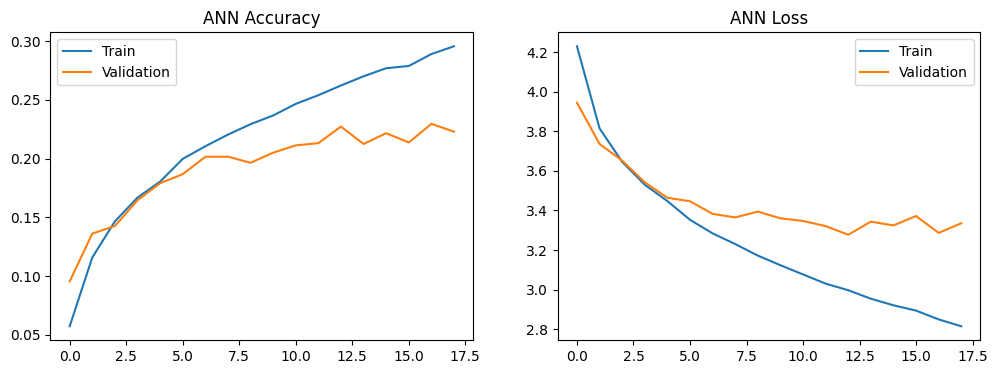

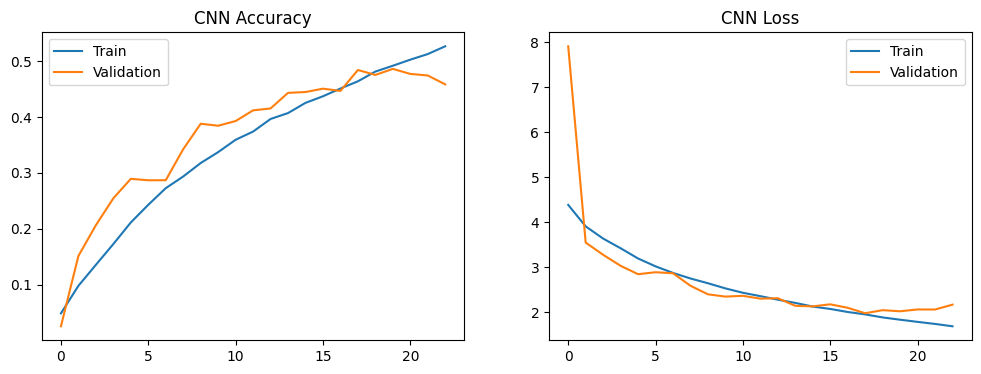

In [15]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(history_ann, "ANN")
plot_history(history_cnn, "CNN")

Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step


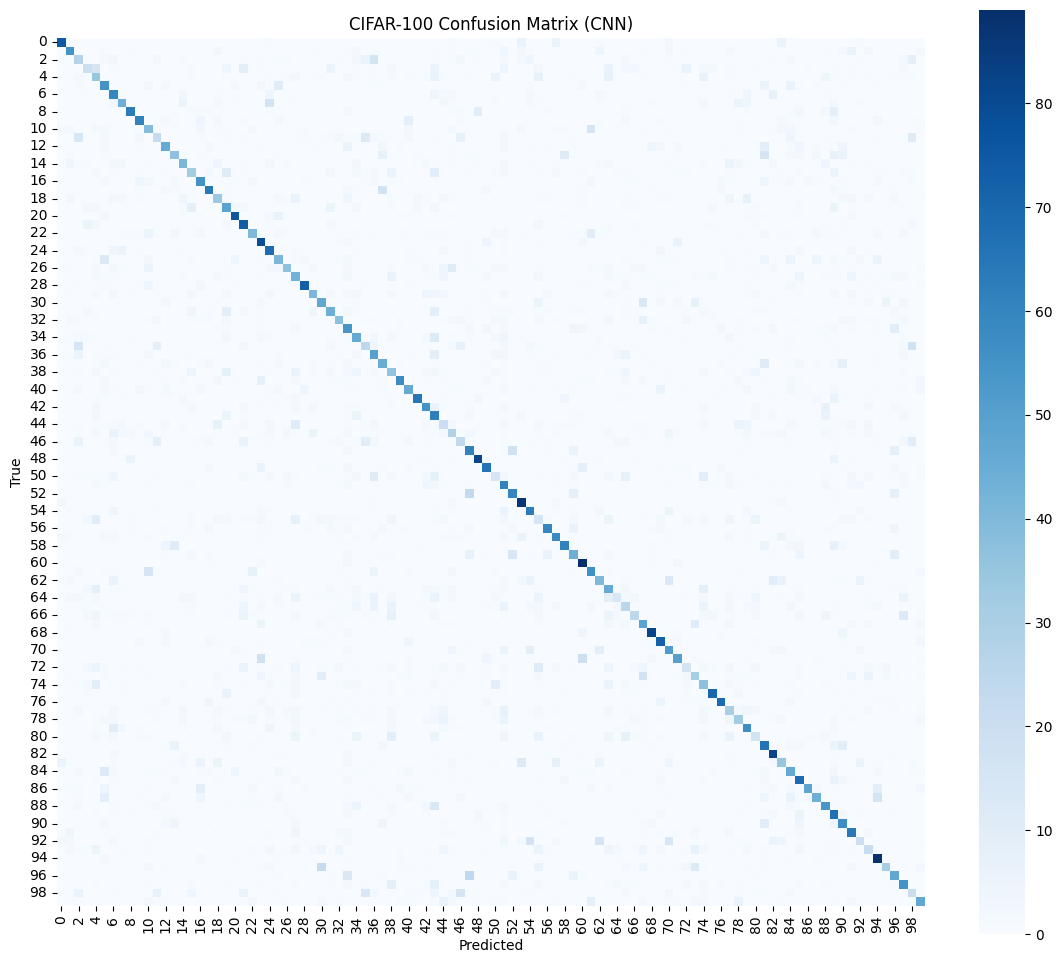

In [18]:
y_pred = cnn_model.predict(cifar100_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = cifar100_test_labels.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues", square=True)
plt.title("CIFAR-100 Confusion Matrix (CNN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Prediction Analysis

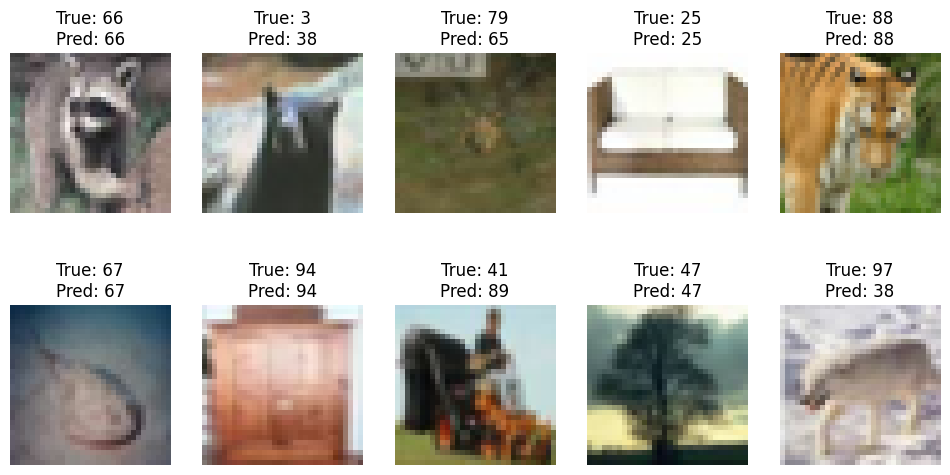

In [19]:
class_names = list(range(100))  # CIFAR-100 has numeric class labels

plt.figure(figsize=(12,6))
for i in range(10):
    idx = np.random.randint(0, len(cifar100_test_images))
    plt.subplot(2,5,i+1)
    plt.imshow(cifar100_test_images[idx])
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis("off")
plt.show()

### Final Learning Summary

1. ANN fails on CIFAR-100 because it ignores spatial structure.

2. CNN significantly outperforms ANN by learning local patterns via convolution.

3. Early stopping prevents overfitting while saving training time.


